# **AI Models Benchmark**

## Business Context

Large language models are now core infrastructure for analytics, software development, and customer-facing systems. Selecting the right model requires balancing intelligence, cost, performance, and user experience across competing vendor ecosystems.

Many organizations make suboptimal choices by prioritizing brand or raw capability over measurable value. This dataset enables a data-driven comparison of leading AI models, supporting clearer trade-off analysis and more defensible, use-case-aligned decisions.

## Core Business Problem

Organizations struggle to choose the right AI language model because performance, cost, speed, and latency vary widely across providers. Without data-driven comparison, model selection becomes subjective, leading to suboptimal cost, poor user experience, or over-engineering. This analysis aims to objectively evaluate AI models to identify optimal trade-offs and value-driven choices.


## Dataset Overview

The dataset contains model-level performance, cost, and efficiency metrics for modern AI language models developed by major vendors. Each row represents a distinct model variant, enabling direct comparison across intelligence, pricing, speed, and latency dimensions.


In [2]:
# Install Libaries

! pip install numpy pandas matplotlib

In [3]:
# Import all required Libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load dataset
df = pd.read_csv("ai_models_performance.csv")

# Basic structure
df.shape

(188, 7)

In [5]:
# Preview data
df.head()


,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),400k,OpenAI,51,$4.81,100,44.29
1,Claude Opus 4.5,200k,Anthropic,49,$10.00,79,1.70
2,Gemini 3 Pro Preview (high),1m,Google,48,$4.50,128,32.19
3,GPT-5.1 (high),400k,OpenAI,47,$3.44,127,26.50
4,Gemini 3 Flash,1m,Google,46,$1.13,224,11.62


In [6]:
# Data types and null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Model                            188 non-null    object 
 1   Context Window                   188 non-null    object 
 2   Creator                          188 non-null    object 
 3   Intelligence Index               188 non-null    object 
 4   Price (Blended USD/1M Tokens)    188 non-null    object 
 5   Speed(median token/s)            188 non-null    int64  
 6   Latency (First Answer Chunk /s)  188 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 10.4+ KB


In [7]:
# Column-wise Data Quality Check
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Model,188,154,Claude Opus 4.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Context Window,188,20,128k,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Creator,188,37,Alibaba,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Intelligence Index,188,64,15,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (Blended USD/1M Tokens),188,65,$0.00,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Speed(median token/s),188.0,NaN,NaN,NaN,89.765957,92.515404,0.0,14.5,72.0,127.25,550.0
Latency (First Answer Chunk /s),188.0,NaN,NaN,NaN,3.313351,12.711482,0.0,0.2175,0.52,1.0825,113.01


**Cleaning the Context Window Column**

To compare context capacity, values must be converted into a single numeric unit.

- k → × 1,000
- m → × 1,000,000
- Result stored as integer tokens

In [8]:
def parse_context_window(value):
    value = value.lower().strip()
    if 'k' in value:
        return int(float(value.replace('k', '')) * 1_000)
    elif 'm' in value:
        return int(float(value.replace('m', '')) * 1_000_000)
    else:
        return np.nan

df['Context_Window_Tokens'] = df['Context Window'].apply(parse_context_window)


In [9]:
df[['Context Window', 'Context_Window_Tokens']].head()


,Context Window,Context_Window_Tokens
0,400k,400000
1,200k,200000
2,1m,1000000
3,400k,400000
4,1m,1000000


**Cleaning Price Column**

Cost analysis is impossible unless price is a true numeric value.

- Remove $
- Convert to float
- Preserve USD scale

In [10]:
df['Price_USD_per_1M'] = (
    df['Price (Blended USD/1M Tokens)']
    .str.replace('$', '', regex=False)
    .astype(float)
)


In [11]:
df['Price_USD_per_1M'].describe()


count    188.000000
mean       0.972553
std        1.644017
min        0.000000
25%        0.000000
50%        0.300000
75%        0.900000
max       10.000000
Name: Price_USD_per_1M, dtype: float64

**Validate Speed and Latency Columns**

Ensure existing numeric fields contain no logical errors.

In [12]:
# Check for negative or zero values
(df['Speed(median token/s)'] <= 0).sum(), (df['Latency (First Answer Chunk /s)'] <= 0).sum()


(np.int64(46), np.int64(46))

In [13]:
df[['Speed(median token/s)', 'Latency (First Answer Chunk /s)']].describe()


,Speed(median token/s),Latency (First Answer Chunk /s)
count,188.000000,188.000000
mean,89.765957,3.313351
std,92.515404,12.711482
min,0.000000,0.000000
25%,14.500000,0.217500
50%,72.000000,0.520000
75%,127.250000,1.082500
max,550.000000,113.010000


In [14]:
df.head()

,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s),Context_Window_Tokens,Price_USD_per_1M
0,GPT-5.2 (xhigh),400k,OpenAI,51,$4.81,100,44.29,400000,4.81
1,Claude Opus 4.5,200k,Anthropic,49,$10.00,79,1.70,200000,10.00
2,Gemini 3 Pro Preview (high),1m,Google,48,$4.50,128,32.19,1000000,4.50
3,GPT-5.1 (high),400k,OpenAI,47,$3.44,127,26.50,400000,3.44
4,Gemini 3 Flash,1m,Google,46,$1.13,224,11.62,1000000,1.13


In [15]:
# convert STRING to NUMERIC Column
df['Intelligence_Index'] = pd.to_numeric(
    df['Intelligence Index'],
    errors='coerce'
)
df[['Intelligence Index', 'Intelligence_Index']].head()


,Intelligence Index,Intelligence_Index
0,51,51.0
1,49,49.0
2,48,48.0
3,47,47.0
4,46,46.0


**Clean Dataset Structure**

In [16]:
clean_df = df[
    [
        'Model',
        'Creator',
        'Context_Window_Tokens',
        'Intelligence_Index',
        'Price_USD_per_1M',
        'Speed(median token/s)',
        'Latency (First Answer Chunk /s)'
    ]
]

clean_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Model                            188 non-null    object 
 1   Creator                          188 non-null    object 
 2   Context_Window_Tokens            188 non-null    int64  
 3   Intelligence_Index               137 non-null    float64
 4   Price_USD_per_1M                 188 non-null    float64
 5   Speed(median token/s)            188 non-null    int64  
 6   Latency (First Answer Chunk /s)  188 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 10.4+ KB


## **Analyze**

**1. Basic Descriptive Analysis**

Q1.1. How many models are available per creator?

In [17]:
# Count number of models per creator
models_per_creator = clean_df.groupby('Creator')['Model'].count()

models_per_creator


Creator
AI21 Labs                                 3
Alibaba                                  28
Allen Institute for AI                    4
Amazon                                   11
Anthropic                                 6
Baidu                                     2
ByteDance Seed                            2
Cohere                                    1
Deep Cogito                               1
DeepSeek                                  9
Google                                   14
IBM                                       6
InclusionAI                               4
Kimi                                      3
Korea Telecom                             2
KwaiKAT                                   1
LG AI Research                            6
Liquid AI                                 3
MBZUAI Institute of Foundation Models     3
Meta                                      6
Microsoft Azure                           3
MiniMax                                   2
Mistral                 

Q1.2. What is the overall range of intelligence, price, speed, and latency?

In [18]:
# Range (min and max) of key metrics
metric_ranges = clean_df.agg({
    'Intelligence_Index': ['min', 'max'],
    'Price_USD_per_1M': ['min', 'max'],
    'Speed(median token/s)': ['min', 'max'],
    'Latency (First Answer Chunk /s)': ['min', 'max']
})

metric_ranges


,Intelligence_Index,Price_USD_per_1M,Speed(median token/s),Latency (First Answer Chunk /s)
min,6.0,0.0,0,0.00
max,51.0,10.0,550,113.01


Q1.3. Are there obvious outliers in the dataset?

In [19]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

outliers = {
    'Intelligence_Index': detect_outliers(clean_df['Intelligence_Index']),
    'Price_USD_per_1M': detect_outliers(clean_df['Price_USD_per_1M']),
    'Speed(median token/s)': detect_outliers(clean_df['Speed(median token/s)']),
    'Latency (First Answer Chunk /s)': detect_outliers(clean_df['Latency (First Answer Chunk /s)'])
}

outliers


{'Intelligence_Index': Series([], Name: Intelligence_Index, dtype: float64),
 'Price_USD_per_1M': 0       4.81
 1      10.00
 2       4.50
 3       3.44
 5       4.81
 6      10.00
 7       6.00
 9       3.44
 10      6.00
 12      3.50
 14      4.50
 20      6.00
 24      3.44
 27      3.44
 32      4.81
 34      2.40
 36      3.44
 39      2.40
 43      2.63
 45      2.63
 50      2.63
 51      2.75
 52      2.36
 57      3.00
 70      3.44
 95      5.00
 133     4.19
 140     4.38
 162     3.50
 Name: Price_USD_per_1M, dtype: float64,
 'Speed(median token/s)': 33     366
 64     307
 77     550
 90     429
 147    298
 149    462
 182    322
 Name: Speed(median token/s), dtype: int64,
 'Latency (First Answer Chunk /s)': 0       44.29
 2       32.19
 3       26.50
 4       11.62
 9       17.80
 10       6.34
 12      12.44
 13     113.01
 14       4.04
 18       6.15
 19       8.53
 24      21.03
 26       4.11
 27      32.99
 36      12.47
 42      15.06
 53     111.22
 55       8.7

Q1.4. Do creators differ in portfolio size?

In [20]:
portfolio_stats = models_per_creator.describe()

portfolio_stats


count    37.000000
mean      5.081081
std       5.499386
min       1.000000
25%       1.000000
50%       3.000000
75%       6.000000
max      28.000000
Name: Model, dtype: float64

Q1.5. Is the dataset skewed toward any single vendor?

In [21]:
# Percentage distribution of models by creator
creator_distribution = (
    clean_df['Creator']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

creator_distribution


Creator
Alibaba                                  14.89
Google                                    7.45
OpenAI                                    6.91
NVIDIA                                    6.91
Mistral                                   6.38
Amazon                                    5.85
DeepSeek                                  4.79
xAI                                       4.26
Anthropic                                 3.19
IBM                                       3.19
LG AI Research                            3.19
Meta                                      3.19
Nous Research                             3.19
Z AI                                      2.66
Allen Institute for AI                    2.13
InclusionAI                               2.13
MBZUAI Institute of Foundation Models     1.60
Liquid AI                                 1.60
AI21 Labs                                 1.60
Kimi                                      1.60
Microsoft Azure                           1.60
Xiaom

**2. Intelligence vs Price Analysis**

Q2.1. Does higher intelligence always mean higher price?

In [22]:
# Correlation between intelligence and price
intelligence_price_corr = clean_df[
    ['Intelligence_Index', 'Price_USD_per_1M']
].corr().iloc[0, 1]

intelligence_price_corr


np.float64(0.532209318353411)

Q2.2. Are there overpriced low-intelligence models?

In [23]:
# Compute dataset averages
avg_intelligence = clean_df['Intelligence_Index'].mean()
avg_price = clean_df['Price_USD_per_1M'].mean()

# Overpriced, low-intelligence models
overpriced_low_intel = clean_df[
    (clean_df['Intelligence_Index'] < avg_intelligence) &
    (clean_df['Price_USD_per_1M'] > avg_price)
][['Model', 'Creator', 'Intelligence_Index', 'Price_USD_per_1M']]

overpriced_low_intel


,Model,Creator,Intelligence_Index,Price_USD_per_1M
70,Nova 2.0 Pro Preview,Amazon,23.0,3.44
83,Qwen3 VL 235B A22B,Alibaba,21.0,1.23
95,Nova Premier,Amazon,19.0,5.00
104,Qwen3 VL 32B,Alibaba,17.0,1.23
133,Llama 3.1 405B,Meta,14.0,4.19
137,Llama 3.1 Nemotron 70B,NVIDIA,14.0,1.20
140,Command A,Cohere,13.0,4.38
162,Jamba 1.7 Large,AI21 Labs,9.0,3.50


Q2.3. Are there undervalued high-intelligence models?

In [24]:
# Undervalued, high-intelligence models
undervalued_high_intel = clean_df[
    (clean_df['Intelligence_Index'] > avg_intelligence) &
    (clean_df['Price_USD_per_1M'] < avg_price)
][['Model', 'Creator', 'Intelligence_Index', 'Price_USD_per_1M']]

undervalued_high_intel


,Model,Creator,Intelligence_Index,Price_USD_per_1M
8,GLM-4.7,Z AI,42.0,0.94
11,DeepSeek V3.2,DeepSeek,41.0,0.32
13,GPT-5 mini (high),OpenAI,41.0,0.69
16,MiniMax-M2.1,MiniMax,39.0,0.53
17,MiMo-V2-Flash,Xiaomi,39.0,0.15
18,Grok 4.1 Fast,xAI,38.0,0.28
19,GPT-5.1 Codex mini (high),OpenAI,38.0,0.69
22,KAT-Coder-Pro V1,KwaiKAT,36.0,0.00
23,MiniMax-M2,MiniMax,36.0,0.53
26,Grok 4 Fast,xAI,35.0,0.28


Q2.4. What is the intelligence-per-dollar efficiency?

In [25]:
clean_df = clean_df.copy()

# Remove invalid price values
clean_df = clean_df[clean_df['Price_USD_per_1M'] > 0]

# Intelligence per dollar efficiency
clean_df['Intelligence_per_USD'] = (
    clean_df['Intelligence_Index'] / clean_df['Price_USD_per_1M']
)

clean_df['Intelligence_per_USD'].describe()


count    111.000000
mean      55.955568
std       59.572269
min        2.571429
25%       13.741964
50%       32.941176
75%       81.315331
max      260.000000
Name: Intelligence_per_USD, dtype: float64

Q2.5. Top 10 best-value models

In [26]:
best_value_models = clean_df.sort_values(
    by='Intelligence_per_USD',
    ascending=False
)[['Model', 'Creator', 'Intelligence_Index', 'Price_USD_per_1M', 'Intelligence_per_USD']].head(10)

best_value_models


,Model,Creator,Intelligence_Index,Price_USD_per_1M,Intelligence_per_USD
17,MiMo-V2-Flash,Xiaomi,39.0,0.15,260.000000
58,gpt-oss-20B (high),OpenAI,25.0,0.10,250.000000
59,NVIDIA Nemotron 3 Nano,NVIDIA,25.0,0.10,250.000000
119,NVIDIA Nemotron Nano 9B V2,NVIDIA,15.0,0.07,214.285714
81,gpt-oss-20B (low),OpenAI,21.0,0.10,210.000000
41,MiMo-V2-Flash,Xiaomi,30.0,0.15,200.000000
179,Gemma 3n E4B,Google,6.0,0.03,200.000000
53,GPT-5 nano (high),OpenAI,27.0,0.14,192.857143
139,NVIDIA Nemotron 3 Nano,NVIDIA,14.0,0.10,140.000000
18,Grok 4.1 Fast,xAI,38.0,0.28,135.714286


**3. Speed vs Latency Analysis**

Q3.1. Are fast models also low-latency?

In [27]:
# Correlation between speed and latency
speed_latency_corr = clean_df[
    ['Speed(median token/s)', 'Latency (First Answer Chunk /s)']
].corr().iloc[0, 1]

speed_latency_corr


np.float64(0.04251459482020324)

Q3.2. Can a model be fast but slow to respond initially?

In [28]:
# Compute averages
avg_speed = clean_df['Speed(median token/s)'].mean()
avg_latency = clean_df['Latency (First Answer Chunk /s)'].mean()

# Fast but slow-to-start models
fast_slow_start = clean_df[
    (clean_df['Speed(median token/s)'] > avg_speed) &
    (clean_df['Latency (First Answer Chunk /s)'] > avg_latency)
][['Model', 'Creator', 'Speed(median token/s)', 'Latency (First Answer Chunk /s)']]

fast_slow_start


,Model,Creator,Speed(median token/s),Latency (First Answer Chunk /s)
2,Gemini 3 Pro Preview (high),Google,128,32.19
3,GPT-5.1 (high),OpenAI,127,26.50
4,Gemini 3 Flash,Google,224,11.62
9,GPT-5.1 Codex (high),OpenAI,190,17.80
12,o3,OpenAI,264,12.44
18,Grok 4.1 Fast,xAI,150,6.15
19,GPT-5.1 Codex mini (high),OpenAI,174,8.53
24,Nova 2.0 Pro Preview (medium),Amazon,133,21.03
27,Gemini 2.5 Pro,Google,160,32.99
36,Nova 2.0 Pro Preview (low),Amazon,134,12.47


Q3.3. Which models optimize real-time interaction?

In [29]:
# Real-time optimized models
real_time_models = clean_df[
    (clean_df['Latency (First Answer Chunk /s)'] < avg_latency) &
    (clean_df['Speed(median token/s)'] >= avg_speed)
][['Model', 'Creator', 'Speed(median token/s)', 'Latency (First Answer Chunk /s)']]

real_time_models


,Model,Creator,Speed(median token/s),Latency (First Answer Chunk /s)
14,Gemini 3 Pro Preview (low),Google,133,4.04
21,Claude 4.5 Haiku,Anthropic,116,0.46
25,Gemini 3 Flash,Google,196,0.74
26,Grok 4 Fast,xAI,179,4.11
33,gpt-oss-120B (high),OpenAI,366,0.41
35,Grok 3 mini Reasoning (high),xAI,192,0.70
54,Qwen3 Next 80B A3B,Alibaba,177,1.07
58,gpt-oss-20B (high),OpenAI,254,0.47
59,NVIDIA Nemotron 3 Nano,NVIDIA,177,0.31
64,gpt-oss-120B (low),OpenAI,307,0.46


Q3.4. Which models are better for batch processing?

In [30]:
batch_models = clean_df[
    clean_df['Speed(median token/s)'] > avg_speed
][['Model', 'Creator', 'Speed(median token/s)', 'Latency (First Answer Chunk /s)']]

batch_models.sort_values(
    by='Speed(median token/s)',
    ascending=False
)
batch_models.head(10)


,Model,Creator,Speed(median token/s),Latency (First Answer Chunk /s)
2,Gemini 3 Pro Preview (high),Google,128,32.19
3,GPT-5.1 (high),OpenAI,127,26.50
4,Gemini 3 Flash,Google,224,11.62
9,GPT-5.1 Codex (high),OpenAI,190,17.80
12,o3,OpenAI,264,12.44
14,Gemini 3 Pro Preview (low),Google,133,4.04
18,Grok 4.1 Fast,xAI,150,6.15
19,GPT-5.1 Codex mini (high),OpenAI,174,8.53
21,Claude 4.5 Haiku,Anthropic,116,0.46
24,Nova 2.0 Pro Preview (medium),Amazon,133,21.03


Q3.5. Are there extreme trade-offs?

In [31]:
# high latency
extreme_fast_high_latency = clean_df[
    (clean_df['Speed(median token/s)'] > clean_df['Speed(median token/s)'].quantile(0.90)) &
    (clean_df['Latency (First Answer Chunk /s)'] > clean_df['Latency (First Answer Chunk /s)'].quantile(0.90))
]

extreme_fast_high_latency


,Model,Creator,Context_Window_Tokens,Intelligence_Index,Price_USD_per_1M,Speed(median token/s),Latency (First Answer Chunk /s),Intelligence_per_USD
12,o3,OpenAI,200000,NaN,3.50,264,12.44,NaN
42,Nova 2.0 Lite (medium),Amazon,1000000,30.0,0.85,254,15.06,35.294118
151,Granite 4.0 H Small,IBM,128000,11.0,0.11,239,8.74,100.000000


In [32]:
# low latency
extreme_slow_low_latency = clean_df[
    (clean_df['Speed(median token/s)'] < clean_df['Speed(median token/s)'].quantile(0.10)) &
    (clean_df['Latency (First Answer Chunk /s)'] < clean_df['Latency (First Answer Chunk /s)'].quantile(0.10))
]

extreme_slow_low_latency

,Model,Creator,Context_Window_Tokens,Intelligence_Index,Price_USD_per_1M,Speed(median token/s),Latency (First Answer Chunk /s),Intelligence_per_USD
5,GPT-5.2 (medium),OpenAI,400000,45.0,4.81,0,0.0,9.355509
28,DeepSeek V3.2 Speciale,DeepSeek,128000,NaN,0.42,0,0.0,NaN
30,DeepSeek V3.1 Terminus,DeepSeek,128000,33.0,0.80,0,0.0,41.250000
31,Doubao Seed Code,ByteDance Seed,256000,33.0,0.41,0,0.0,80.487805
44,ERNIE 5.0 Thinking Preview,Baidu,128000,29.0,1.47,0,0.0,19.727891
46,DeepSeek V3.1 Terminus,DeepSeek,128000,28.0,0.80,0,0.0,35.000000
47,Nova 2.0 Omni (medium),Amazon,1000000,28.0,0.85,0,0.0,32.941176
52,DeepSeek R1 0528,DeepSeek,128000,27.0,2.36,0,0.0,11.440678
63,Nova 2.0 Omni (low),Amazon,1000000,24.0,0.85,0,0.0,28.235294
187,Doubao-Seed-1.8,ByteDance Seed,256000,NaN,0.15,0,0.0,NaN


**4. Context Window Capability Analysis**

Q4.1. Do large context windows come at a cost?

In [33]:
# Correlation between context window and price
context_price_corr = clean_df[
    ['Context_Window_Tokens', 'Price_USD_per_1M']
].corr().iloc[0, 1]

context_price_corr


np.float64(-0.006155000404908954)

Q4.2. Are high-context models slower or more expensive?

In [34]:
# high-context threshold (top 25%)
context_threshold = clean_df['Context_Window_Tokens'].quantile(0.75)

# Split dataset
high_context = clean_df[clean_df['Context_Window_Tokens'] >= context_threshold]
low_context = clean_df[clean_df['Context_Window_Tokens'] < context_threshold]

# Compare averages
high_vs_low_context = pd.DataFrame({
    'High_Context_Models': high_context[
        ['Price_USD_per_1M', 'Speed(median token/s)']
    ].mean(),
    'Low_Context_Models': low_context[
        ['Price_USD_per_1M', 'Speed(median token/s)']
    ].mean()
})

high_vs_low_context


,High_Context_Models,Low_Context_Models
Price_USD_per_1M,1.832558,1.095158
Speed(median token/s),142.116279,102.789474


Q4.3. Which creators dominate long-context models?

In [35]:
# Maximum context window by creator
max_context_by_creator = clean_df.groupby('Creator')['Context_Window_Tokens'].max()

max_context_by_creator.sort_values(ascending=False)


Creator
Meta                      10000000
xAI                        2000000
Google                     1000000
Anthropic                  1000000
NVIDIA                     1000000
Amazon                     1000000
OpenAI                      400000
Alibaba                     262000
AI21 Labs                   258000
Cohere                      256000
ByteDance Seed              256000
Xiaomi                      256000
Kimi                        256000
Mistral                     256000
MiniMax                     205000
Z AI                        200000
Prime Intellect             131000
LG AI Research              131000
Baidu                       131000
InclusionAI                 131000
Nous Research               128000
Deep Cogito                 128000
DeepSeek                    128000
Reka AI                     128000
IBM                         128000
Allen Institute for AI       66000
Microsoft Azure              16000
Name: Context_Window_Tokens, dtype: int64

Q4.4. Is context window linked to intelligence?

In [36]:
# Correlation between context window tokens and intelligence
context_intel_corr = clean_df[
    ['Context_Window_Tokens', 'Intelligence_Index']
].corr().iloc[0, 1]

context_intel_corr


np.float64(0.015006265330674552)

Q4.5. Is context capacity overkill for most use cases?

In [37]:
# Define practical threshold
practical_context_limit = 128000

# Percentage of models exceeding this limit
overkill_context_pct = (
    (clean_df['Context_Window_Tokens'] > practical_context_limit).mean() * 100
)

overkill_context_pct


np.float64(66.66666666666666)

**5. Creator-Level Aggregation**

Q5.1. Which creator offers the highest average intelligence?

In [38]:
# Average intelligence by creator
avg_intelligence_by_creator = (
    clean_df
    .groupby('Creator')['Intelligence_Index']
    .mean()
    .sort_values(ascending=False)
)

avg_intelligence_by_creator


Creator
Anthropic                 39.666667
MiniMax                   37.500000
OpenAI                    35.583333
Xiaomi                    34.500000
Kimi                      34.000000
ByteDance Seed            33.000000
DeepSeek                  32.200000
xAI                       32.000000
Google                    31.500000
Baidu                     29.000000
Z AI                      28.000000
Amazon                    25.100000
Prime Intellect           22.000000
Alibaba                   19.952381
Mistral                   18.000000
NVIDIA                    15.555556
Meta                      15.500000
LG AI Research            14.500000
Cohere                    13.000000
IBM                       11.000000
Allen Institute for AI     8.000000
AI21 Labs                  8.000000
Deep Cogito                     NaN
InclusionAI                     NaN
Microsoft Azure                 NaN
Nous Research                   NaN
Reka AI                         NaN
Name: Intelligence_I

Q5.2. Who is the most cost-efficient vendor?

In [39]:
# Ensure intelligence-per-dollar exists
if 'Intelligence_per_USD' not in clean_df.columns:
    clean_df['Intelligence_per_USD'] = (
        clean_df['Intelligence_Index'] / clean_df['Price_USD_per_1M']
    )

# Average value efficiency by creator
cost_efficiency_by_creator = (
    clean_df
    .groupby('Creator')['Intelligence_per_USD']
    .mean()
    .sort_values(ascending=False)
)

cost_efficiency_by_creator


Creator
Xiaomi                    230.000000
NVIDIA                    114.365079
IBM                       100.000000
xAI                        87.210317
OpenAI                     86.605990
ByteDance Seed             80.487805
MiniMax                    70.754717
Google                     68.550217
Mistral                    65.461279
DeepSeek                   63.163136
Allen Institute for AI     61.538462
Prime Intellect            52.380952
Z AI                       45.344816
Kimi                       30.358255
Meta                       29.520784
Alibaba                    24.612143
LG AI Research             20.714286
Baidu                      19.727891
Amazon                     19.702161
AI21 Labs                  15.285714
Anthropic                   9.311111
Cohere                      2.968037
Deep Cogito                      NaN
InclusionAI                      NaN
Microsoft Azure                  NaN
Nous Research                    NaN
Reka AI                       

Q5.3. Who optimizes speed best?

In [40]:
# Average speed by creator
avg_speed_by_creator = (
    clean_df
    .groupby('Creator')['Speed(median token/s)']
    .mean()
    .sort_values(ascending=False)
)

avg_speed_by_creator


Creator
IBM                       239.000000
Google                    234.875000
OpenAI                    176.846154
Amazon                    173.727273
xAI                       148.285714
Mistral                   146.000000
InclusionAI               106.000000
NVIDIA                    103.600000
Xiaomi                    101.000000
Alibaba                    94.958333
LG AI Research             94.000000
MiniMax                    89.500000
Anthropic                  87.500000
AI21 Labs                  85.500000
Prime Intellect            85.000000
Meta                       82.833333
Deep Cogito                74.000000
Z AI                       73.600000
Allen Institute for AI     70.000000
Kimi                       68.000000
Cohere                     58.000000
DeepSeek                   54.777778
Nous Research              54.500000
Reka AI                    49.000000
Baidu                      13.500000
Microsoft Azure             7.000000
ByteDance Seed              0.

Q5.4. Who has the lowest latency on average?

In [41]:
# Average latency by creator
avg_latency_by_creator = (
    clean_df
    .groupby('Creator')['Latency (First Answer Chunk /s)']
    .mean()
    .sort_values()
)

avg_latency_by_creator


Creator
ByteDance Seed             0.000000
Cohere                     0.300000
LG AI Research             0.310000
NVIDIA                     0.347000
Mistral                    0.367000
Deep Cogito                0.380000
Meta                       0.456667
Allen Institute for AI     0.475000
DeepSeek                   0.562222
Prime Intellect            0.570000
Kimi                       0.595000
Nous Research              0.675000
Z AI                       0.680000
AI21 Labs                  0.735000
Microsoft Azure            0.760000
Baidu                      0.940000
Alibaba                    1.110833
Anthropic                  1.275000
Reka AI                    1.300000
InclusionAI                1.463333
MiniMax                    1.535000
Xiaomi                     1.705000
xAI                        3.928571
Amazon                     5.342727
IBM                        8.740000
Google                    10.813750
OpenAI                    25.862308
Name: Latency (First

Q5.5. Are creators specializing or balancing?

In [42]:
# Combine creator-level metrics
creator_profile = clean_df.groupby('Creator').agg({
    'Intelligence_Index': 'mean',
    'Price_USD_per_1M': 'mean',
    'Speed(median token/s)': 'mean',
    'Latency (First Answer Chunk /s)': 'mean',
    'Intelligence_per_USD': 'mean'
}).round(2)

creator_profile


,Intelligence_Index,Price_USD_per_1M,Speed(median token/s),Latency (First Answer Chunk /s),Intelligence_per_USD
Creator,,,,,
AI21 Labs,8.00,1.88,85.50,0.74,15.29
Alibaba,19.95,1.18,94.96,1.11,24.61
Allen Institute for AI,8.00,0.14,70.00,0.48,61.54
Amazon,25.10,1.86,173.73,5.34,19.70
Anthropic,39.67,6.00,87.50,1.28,9.31
Baidu,29.00,0.98,13.50,0.94,19.73
ByteDance Seed,33.00,0.28,0.00,0.00,80.49
Cohere,13.00,4.38,58.00,0.30,2.97
Deep Cogito,NaN,1.25,74.00,0.38,NaN


**6. Identifying Balanced Models**

Q6.1. Which models score above average on all key metrics?

In [43]:
# Compute global averages
avg_metrics = {
    'Intelligence_Index': clean_df['Intelligence_Index'].mean(),
    'Speed': clean_df['Speed(median token/s)'].mean(),
    'Latency': clean_df['Latency (First Answer Chunk /s)'].mean()
}

# Models above average on all key dimensions
balanced_models = clean_df[
    (clean_df['Intelligence_Index'] >= avg_metrics['Intelligence_Index']) &
    (clean_df['Speed(median token/s)'] >= avg_metrics['Speed']) &
    (clean_df['Latency (First Answer Chunk /s)'] <= avg_metrics['Latency'])
][['Model', 'Creator', 'Intelligence_Index',
   'Speed(median token/s)', 'Latency (First Answer Chunk /s)']]

balanced_models


,Model,Creator,Intelligence_Index,Speed(median token/s),Latency (First Answer Chunk /s)
14,Gemini 3 Pro Preview (low),Google,41.0,133,4.04
21,Claude 4.5 Haiku,Anthropic,37.0,116,0.46
25,Gemini 3 Flash,Google,35.0,196,0.74
26,Grok 4 Fast,xAI,35.0,179,4.11
33,gpt-oss-120B (high),OpenAI,33.0,366,0.41
35,Grok 3 mini Reasoning (high),xAI,32.0,192,0.70
54,Qwen3 Next 80B A3B,Alibaba,27.0,177,1.07


Q6.2. Are there “no-compromise” models?

In [44]:
# Quantile thresholds
intel_q75 = clean_df['Intelligence_Index'].quantile(0.75)
speed_q75 = clean_df['Speed(median token/s)'].quantile(0.75)
latency_q25 = clean_df['Latency (First Answer Chunk /s)'].quantile(0.25)

no_compromise_models = clean_df[
    (clean_df['Intelligence_Index'] >= intel_q75) &
    (clean_df['Speed(median token/s)'] >= speed_q75) &
    (clean_df['Latency (First Answer Chunk /s)'] <= latency_q25)
][['Model', 'Creator']]

no_compromise_models


,Model,Creator
33,gpt-oss-120B (high),OpenAI


Q6.3. Which models fail badly on one dimension?

In [45]:
# Define extreme thresholds
intel_top = clean_df['Intelligence_Index'].quantile(0.90)
speed_top = clean_df['Speed(median token/s)'].quantile(0.90)
latency_worst = clean_df['Latency (First Answer Chunk /s)'].quantile(0.90)

# High intelligence but very poor latency
intel_bad_latency = clean_df[
    (clean_df['Intelligence_Index'] >= intel_top) &
    (clean_df['Latency (First Answer Chunk /s)'] >= latency_worst)
][['Model', 'Creator', 'Intelligence_Index', 'Latency (First Answer Chunk /s)']]

intel_bad_latency


,Model,Creator,Intelligence_Index,Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),OpenAI,51.0,44.29
2,Gemini 3 Pro Preview (high),Google,48.0,32.19
3,GPT-5.1 (high),OpenAI,47.0,26.50
4,Gemini 3 Flash,Google,46.0,11.62
9,GPT-5.1 Codex (high),OpenAI,42.0,17.80
13,GPT-5 mini (high),OpenAI,41.0,113.01


In [46]:
# Very fast but low intelligence
speed_low_intel = clean_df[
    (clean_df['Speed(median token/s)'] >= speed_top) &
    (clean_df['Intelligence_Index'] <= clean_df['Intelligence_Index'].quantile(0.10))
][['Model', 'Creator', 'Speed(median token/s)', 'Intelligence_Index']]

speed_low_intel

,Model,Creator,Speed(median token/s),Intelligence_Index
147,Ministral 3B (Dec '25),Mistral,298,12.0
151,Granite 4.0 H Small,IBM,239,11.0


Q6.4. How rare are balanced performers?

In [47]:
# Percentage of balanced models
balanced_percentage = (
    len(balanced_models) / len(clean_df)
) * 100

balanced_percentage


5.072463768115942

Q6.5. What trade-offs are unavoidable?

In [48]:
# Correlation matrix for key metrics
tradeoff_matrix = clean_df[
    ['Intelligence_Index',
     'Price_USD_per_1M',
     'Speed(median token/s)',
     'Latency (First Answer Chunk /s)']
].corr()

tradeoff_matrix


,Intelligence_Index,Price_USD_per_1M,Speed(median token/s),Latency (First Answer Chunk /s)
Intelligence_Index,1.000000,0.507819,-0.084304,0.297142
Price_USD_per_1M,0.507819,1.000000,-0.196757,0.089929
Speed(median token/s),-0.084304,-0.196757,1.000000,0.042515
Latency (First Answer Chunk /s),0.297142,0.089929,0.042515,1.000000


**7. Use-Case**

Q7.1. Which models are best suited for Data Scientists & ML Engineers?

In [49]:
# Define thresholds
intel_high = clean_df['Intelligence_Index'].quantile(0.75)
context_large = clean_df['Context_Window_Tokens'].quantile(0.75)

# Suitable models
ds_ml_models = clean_df[
    (clean_df['Intelligence_Index'] >= intel_high) &
    (clean_df['Context_Window_Tokens'] >= context_large)
][['Model', 'Creator', 'Intelligence_Index', 'Context_Window_Tokens']]

ds_ml_models


,Model,Creator,Intelligence_Index,Context_Window_Tokens
0,GPT-5.2 (xhigh),OpenAI,51.0,400000
2,Gemini 3 Pro Preview (high),Google,48.0,1000000
3,GPT-5.1 (high),OpenAI,47.0,400000
4,Gemini 3 Flash,Google,46.0,1000000
5,GPT-5.2 (medium),OpenAI,45.0,400000
7,Claude 4.5 Sonnet,Anthropic,42.0,1000000
9,GPT-5.1 Codex (high),OpenAI,42.0,400000
13,GPT-5 mini (high),OpenAI,41.0,400000
14,Gemini 3 Pro Preview (low),Google,41.0,1000000
18,Grok 4.1 Fast,xAI,38.0,2000000


Q7.2. Which models are best suited for Business Analysts?

In [50]:
# Define thresholds
value_high = clean_df['Intelligence_per_USD'].quantile(0.75)
latency_ok = clean_df['Latency (First Answer Chunk /s)'].quantile(0.50)

# Suitable models
business_analyst_models = clean_df[
    (clean_df['Intelligence_per_USD'] >= value_high) &
    (clean_df['Latency (First Answer Chunk /s)'] <= latency_ok)
][['Model', 'Creator', 'Intelligence_per_USD', 'Latency (First Answer Chunk /s)']]

business_analyst_models


,Model,Creator,Intelligence_per_USD,Latency (First Answer Chunk /s)
33,gpt-oss-120B (high),OpenAI,126.923077,0.41
35,Grok 3 mini Reasoning (high),xAI,91.428571,0.70
58,gpt-oss-20B (high),OpenAI,250.000000,0.47
59,NVIDIA Nemotron 3 Nano,NVIDIA,250.000000,0.31
64,gpt-oss-120B (low),OpenAI,92.307692,0.46
72,Grok 4 Fast,xAI,82.142857,0.58
81,gpt-oss-20B (low),OpenAI,210.000000,0.55
90,Gemini 2.5 Flash-Lite (Sep),Google,117.647059,0.33
94,Llama Nemotron Super 49B v1.5,NVIDIA,111.764706,0.22
116,Devstral Small,Mistral,100.000000,0.36


Q7.3. Which models are most suitable for Researchers?

In [51]:
# Top intelligence and context models
research_models = clean_df[
    clean_df['Intelligence_Index'] >= clean_df['Intelligence_Index'].quantile(0.90)
][['Model', 'Creator', 'Intelligence_Index', 'Context_Window_Tokens']]

research_models


,Model,Creator,Intelligence_Index,Context_Window_Tokens
0,GPT-5.2 (xhigh),OpenAI,51.0,400000
1,Claude Opus 4.5,Anthropic,49.0,200000
2,Gemini 3 Pro Preview (high),Google,48.0,1000000
3,GPT-5.1 (high),OpenAI,47.0,400000
4,Gemini 3 Flash,Google,46.0,1000000
5,GPT-5.2 (medium),OpenAI,45.0,400000
6,Claude Opus 4.5,Anthropic,43.0,200000
7,Claude 4.5 Sonnet,Anthropic,42.0,1000000
8,GLM-4.7,Z AI,42.0,200000
9,GPT-5.1 Codex (high),OpenAI,42.0,400000


Q7.4. Which models are best for Developers (real-time applications)?

In [52]:
# Real-time developer models
developer_models = clean_df[
    (clean_df['Latency (First Answer Chunk /s)'] <= clean_df['Latency (First Answer Chunk /s)'].quantile(0.25)) &
    (clean_df['Speed(median token/s)'] >= clean_df['Speed(median token/s)'].quantile(0.50))
][['Model', 'Creator', 'Speed(median token/s)', 'Latency (First Answer Chunk /s)']]

developer_models


,Model,Creator,Speed(median token/s),Latency (First Answer Chunk /s)
33,gpt-oss-120B (high),OpenAI,366,0.41
59,NVIDIA Nemotron 3 Nano,NVIDIA,177,0.31
74,Magistral Small 1.2,Mistral,205,0.33
80,Mistral Medium 3.1,Mistral,98,0.40
90,Gemini 2.5 Flash-Lite (Sep),Google,429,0.33
105,EXAONE 4.0 32B,LG AI Research,101,0.31
111,Ministral 14B (Dec '25),Mistral,144,0.30
116,Devstral Small,Mistral,228,0.36
119,NVIDIA Nemotron Nano 9B V2,NVIDIA,100,0.23
125,Ministral 8B (Dec '25),Mistral,194,0.28


Q7.5. Which models are suitable for “Other” or General Users?

In [53]:
# Balanced models reused
general_user_models = balanced_models[['Model', 'Creator']]

general_user_models


,Model,Creator
14,Gemini 3 Pro Preview (low),Google
21,Claude 4.5 Haiku,Anthropic
25,Gemini 3 Flash,Google
26,Grok 4 Fast,xAI
33,gpt-oss-120B (high),OpenAI
35,Grok 3 mini Reasoning (high),xAI
54,Qwen3 Next 80B A3B,Alibaba


## **Visualization**

Dashboard 1 - Creator-Level Dashboard

In [54]:
# Top 10 creators by number of models
top_10_creators = (
    clean_df['Creator']
    .value_counts()
    .head(10)
    .index
)


In [55]:
# Filter dataset to top 10 creators
top_10_df = clean_df[clean_df['Creator'].isin(top_10_creators)]


In [56]:
creator_summary = top_10_df.groupby('Creator').agg({
    'Intelligence_Index': 'mean',
    'Price_USD_per_1M': 'mean',
    'Speed(median token/s)': 'mean',
    'Latency (First Answer Chunk /s)': 'mean'
}).round(2)


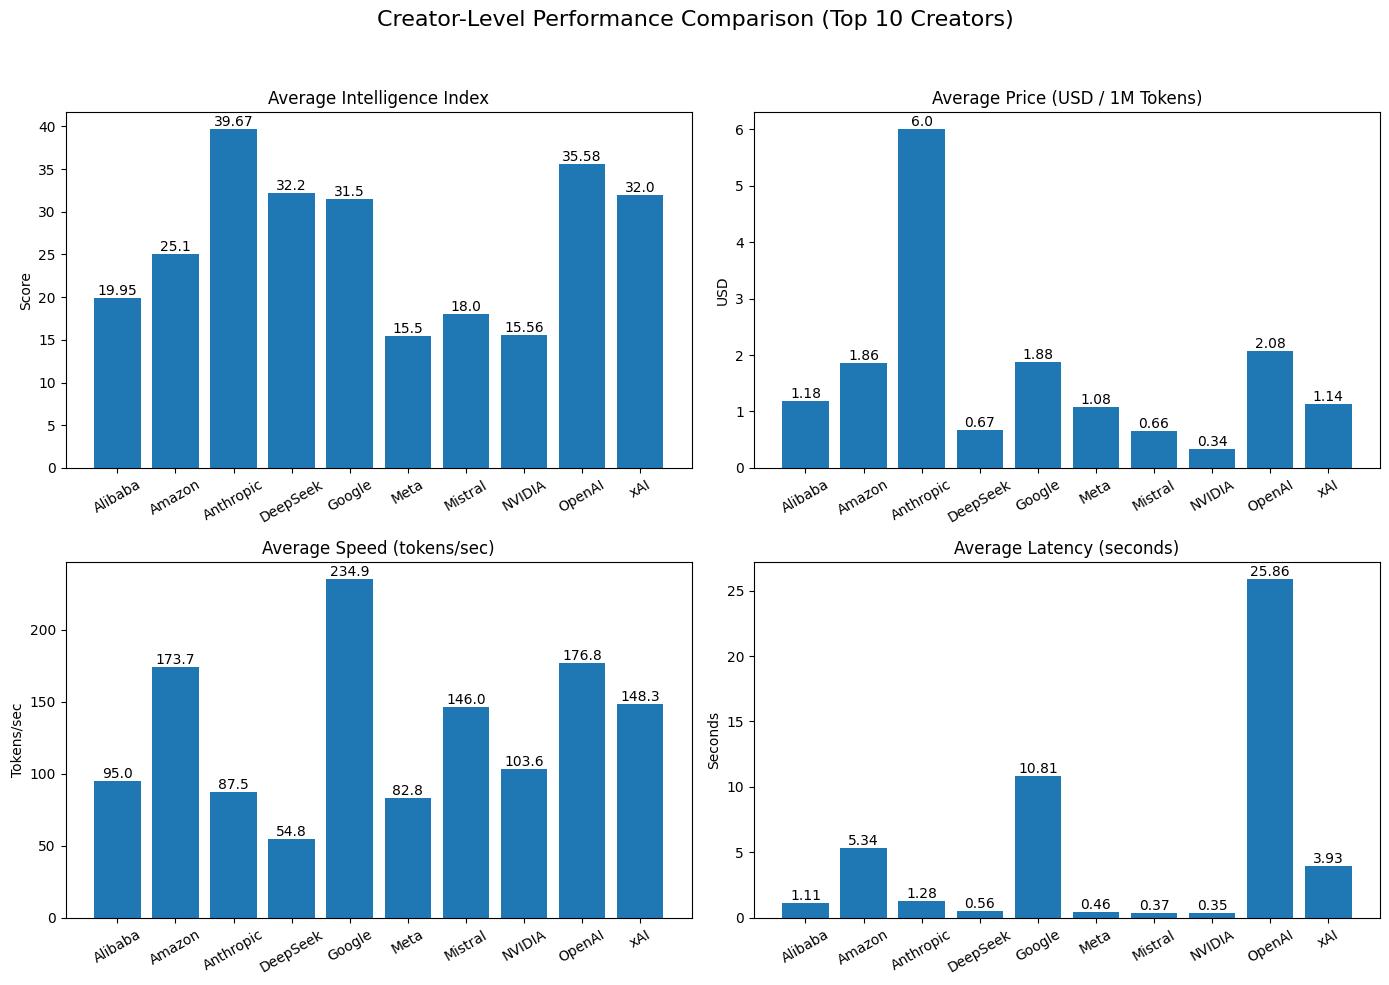

In [57]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Creator-Level Performance Comparison (Top 10 Creators)', fontsize=16)

# 1. Intelligence
axes[0, 0].bar(
    creator_summary.index,
    creator_summary['Intelligence_Index']
)
axes[0, 0].set_title('Average Intelligence Index')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=30)

for i, v in enumerate(creator_summary['Intelligence_Index']):
    axes[0, 0].text(i, v, round(v, 2), ha='center', va='bottom')

# 2. Price
axes[0, 1].bar(
    creator_summary.index,
    creator_summary['Price_USD_per_1M']
)
axes[0, 1].set_title('Average Price (USD / 1M Tokens)')
axes[0, 1].set_ylabel('USD')
axes[0, 1].tick_params(axis='x', rotation=30)

for i, v in enumerate(creator_summary['Price_USD_per_1M']):
    axes[0, 1].text(i, v, round(v, 2), ha='center', va='bottom')

# 3. Speed
axes[1, 0].bar(
    creator_summary.index,
    creator_summary['Speed(median token/s)']
)
axes[1, 0].set_title('Average Speed (tokens/sec)')
axes[1, 0].set_ylabel('Tokens/sec')
axes[1, 0].tick_params(axis='x', rotation=30)

for i, v in enumerate(creator_summary['Speed(median token/s)']):
    axes[1, 0].text(i, v, round(v, 1), ha='center', va='bottom')

# 4. Latency
axes[1, 1].bar(
    creator_summary.index,
    creator_summary['Latency (First Answer Chunk /s)']
)
axes[1, 1].set_title('Average Latency (seconds)')
axes[1, 1].set_ylabel('Seconds')
axes[1, 1].tick_params(axis='x', rotation=30)

for i, v in enumerate(creator_summary['Latency (First Answer Chunk /s)']):
    axes[1, 1].text(i, v, round(v, 2), ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('creator_level_dashboard_top10.png', dpi=300)
plt.show()


**Dashboard 2 — Intelligence vs Price**

In [58]:
clean_df = clean_df.copy()

clean_df['Price_Band'] = pd.qcut(
    clean_df['Price_USD_per_1M'],
    q=4,
    labels=['Low Price', 'Mid-Low Price', 'Mid-High Price', 'High Price']
)

In [59]:
# Top 5 Models per Price Segment
price_bands = ['Low Price', 'Mid-Low Price', 'Mid-High Price', 'High Price']

top5_by_band = {
    band: (
        clean_df[clean_df['Price_Band'] == band]
        .sort_values('Intelligence_Index', ascending=False)
        .head(5)
    )
    for band in price_bands
}



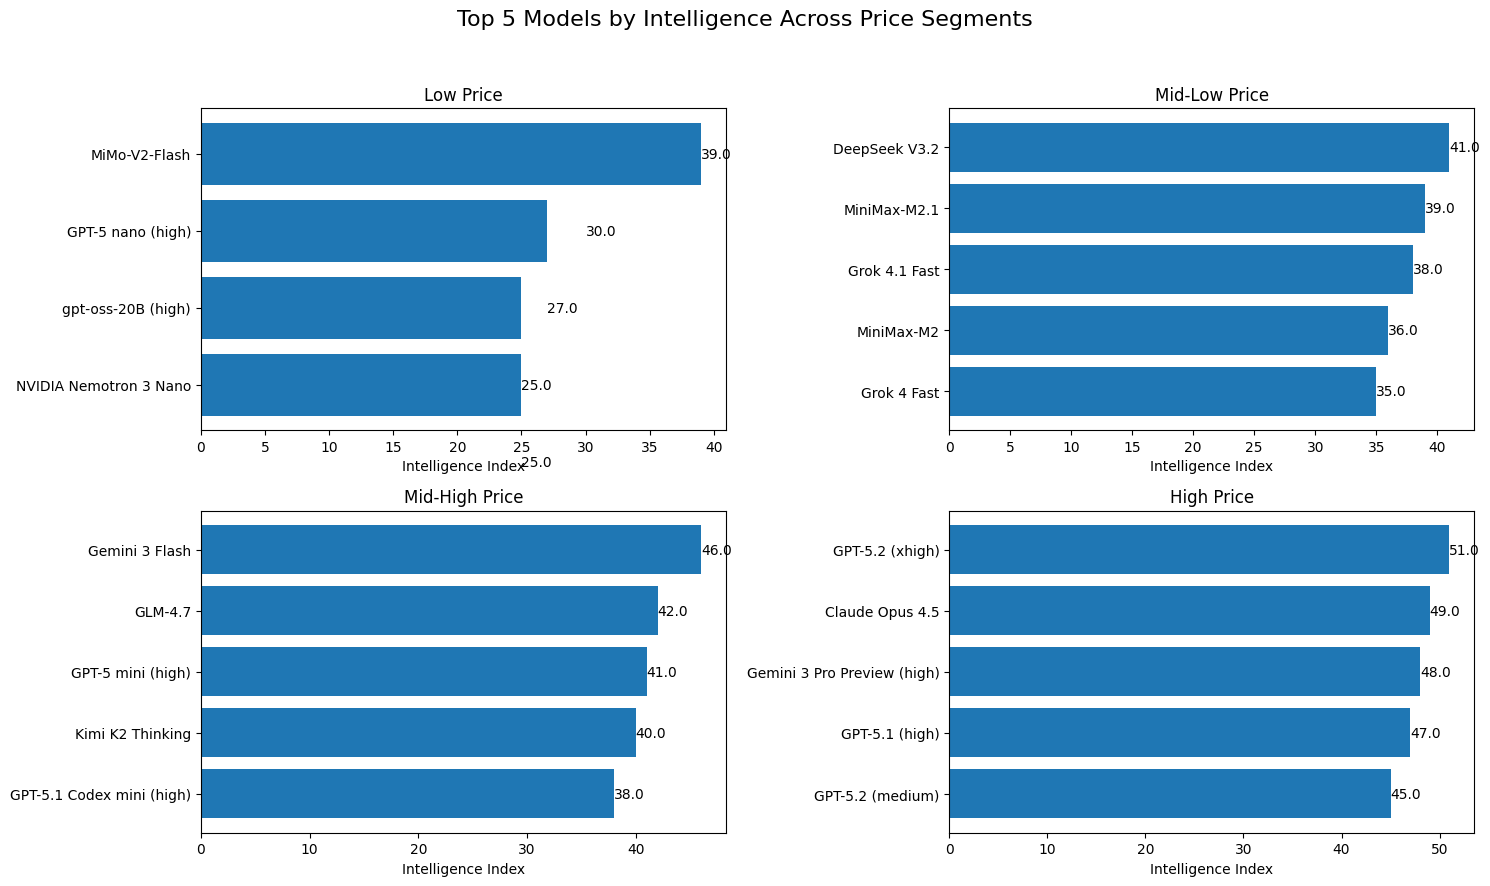

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Top 5 Models by Intelligence Across Price Segments', fontsize=16)

for ax, band in zip(axes.flatten(), price_bands):
    data = top5_by_band[band]
    
    ax.barh(
        data['Model'],
        data['Intelligence_Index']
    )
    
    ax.set_title(band)
    ax.set_xlabel('Intelligence Index')
    ax.invert_yaxis()  # Highest on top
    
    # Add value labels
    for i, v in enumerate(data['Intelligence_Index']):
        ax.text(v, i, f'{round(v, 2)}', va='center', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('dashboard_intelligence_vs_price_top5_models.png', dpi=300)
plt.show()


**Dashboard 3 — Speed vs Latency**

In [61]:
# Aggregate speed and latency by creator
speed_latency_creator = (
    clean_df
    .groupby('Creator')
    .agg({
        'Speed(median token/s)': 'mean',
        'Latency (First Answer Chunk /s)': 'mean'
    })
    .round(2).head(15)
)


In [62]:
# Sort creators by Speed (high to low)
speed_latency_sorted = (
    speed_latency_creator
    .sort_values('Speed(median token/s)', ascending=False)
)


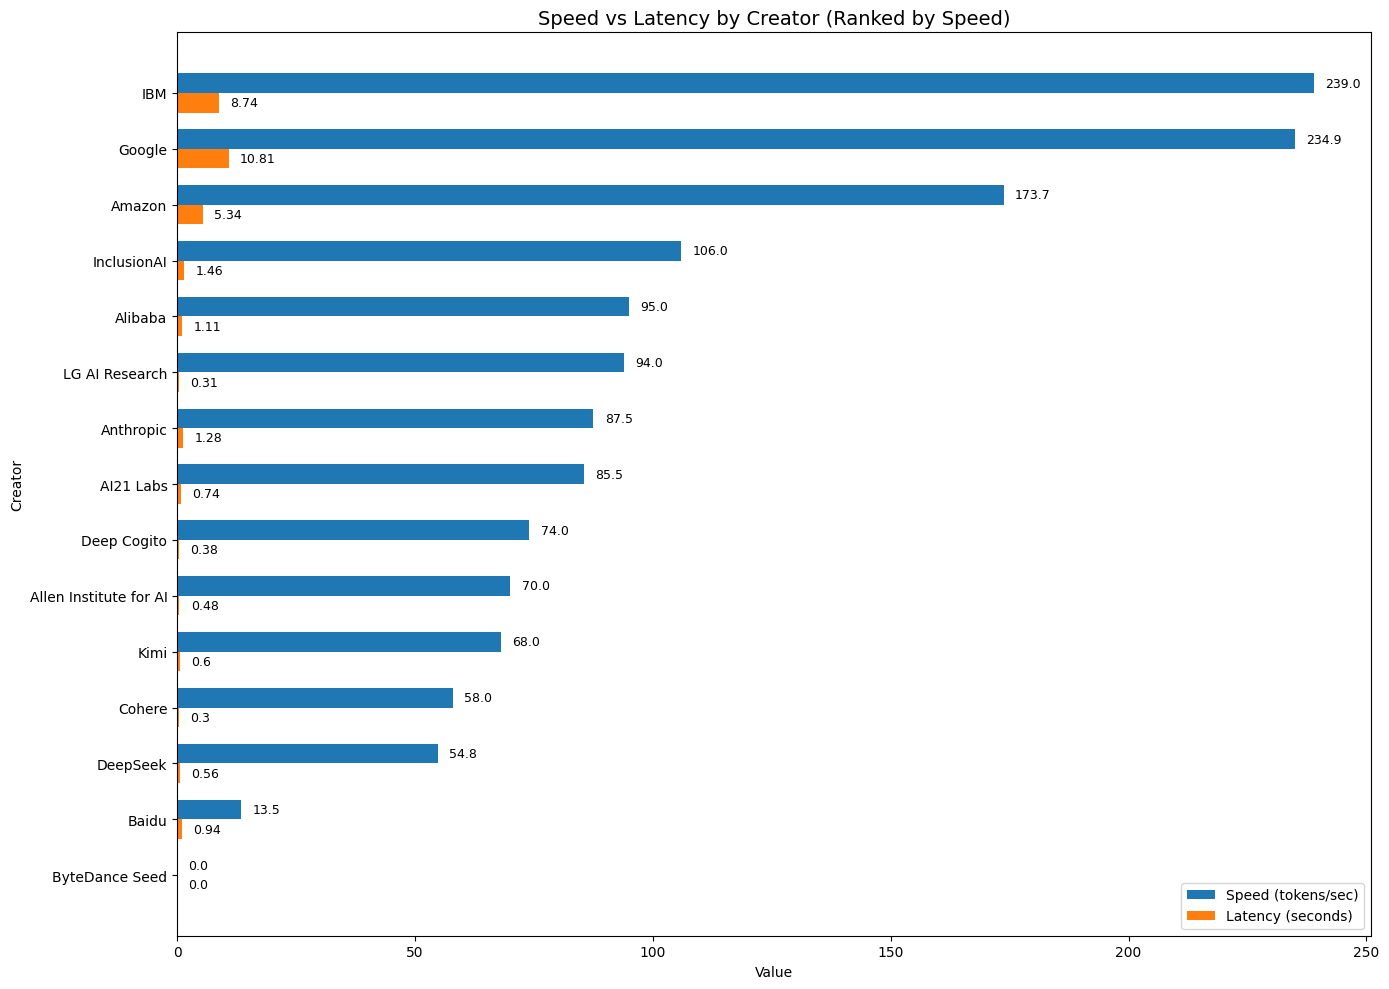

In [63]:
labels = speed_latency_sorted.index.tolist()
speed = speed_latency_sorted['Speed(median token/s)'].values
latency = speed_latency_sorted['Latency (First Answer Chunk /s)'].values

y = np.arange(len(labels))
height = 0.35

plt.figure(figsize=(14, 10))

# Horizontal grouped bars
plt.barh(y - height/2, speed, height, label='Speed (tokens/sec)')
plt.barh(y + height/2, latency, height, label='Latency (seconds)')

plt.title('Speed vs Latency by Creator (Ranked by Speed)', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Creator')

plt.yticks(y, labels)
plt.gca().invert_yaxis()  # Fastest at top
plt.legend()

# Add value labels
max_speed = speed.max()

for i in range(len(labels)):
    plt.text(
        speed[i] + max_speed * 0.01,
        y[i] - height/2,
        round(speed[i], 1),
        va='center',
        fontsize=9
    )
    plt.text(
        latency[i] + max_speed * 0.01,
        y[i] + height/2,
        round(latency[i], 2),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('dashboard_speed_vs_latency_ranked_by_speed.png', dpi=300)
plt.show()


**Dashboard 4 — Context Window Capability Analysis**

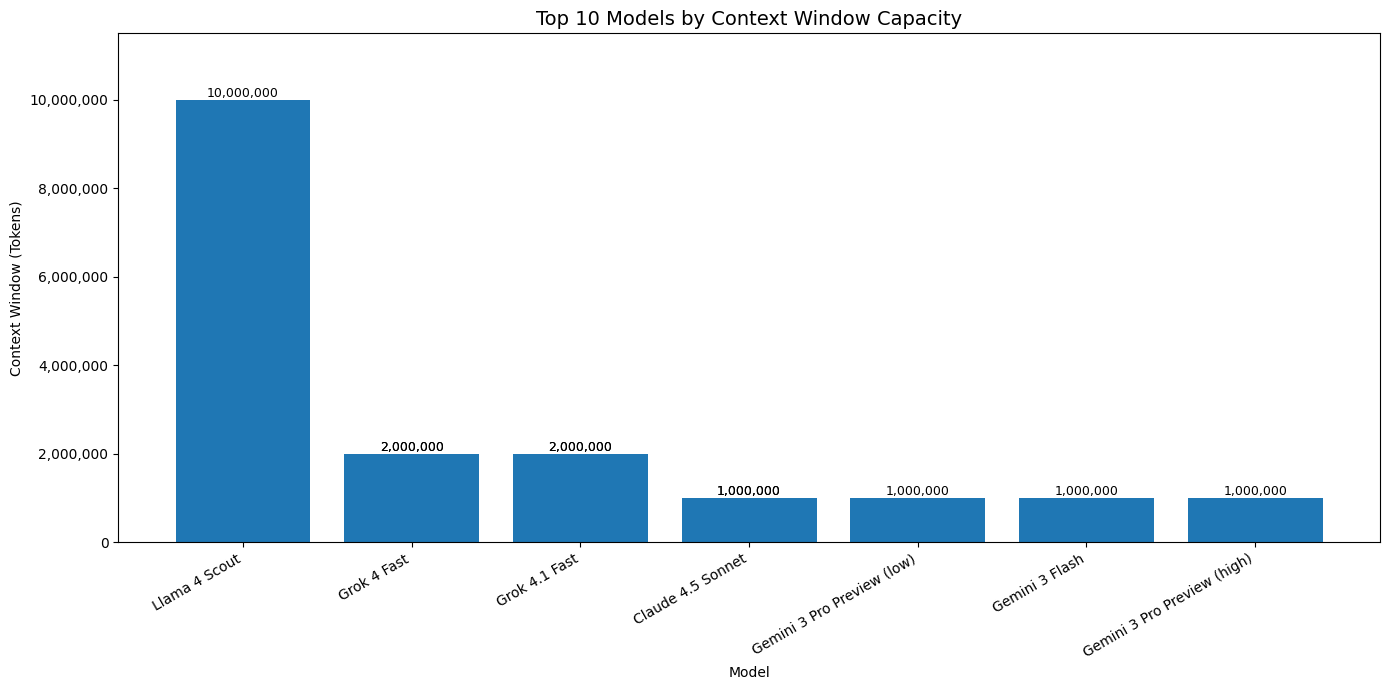

In [64]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Top 10 models by context window
top_10_context_models = (
    clean_df
    .sort_values('Context_Window_Tokens', ascending=False)
    .head(10)
)

# Chart
plt.figure(figsize=(14, 7))

bars = plt.bar(
    top_10_context_models['Model'],
    top_10_context_models['Context_Window_Tokens']
)

plt.title('Top 10 Models by Context Window Capacity', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Context Window (Tokens)')

# Rotate labels properly
plt.xticks(rotation=30, ha='right')

# Format Y-axis with commas (remove scientific notation)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Add headroom so labels don’t hit the top
plt.ylim(0, top_10_context_models['Context_Window_Tokens'].max() * 1.15)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('top_10_context_window_models_fixed.png', dpi=300)
plt.show()


**Dashboard 5 — Creator-Level Aggregation**

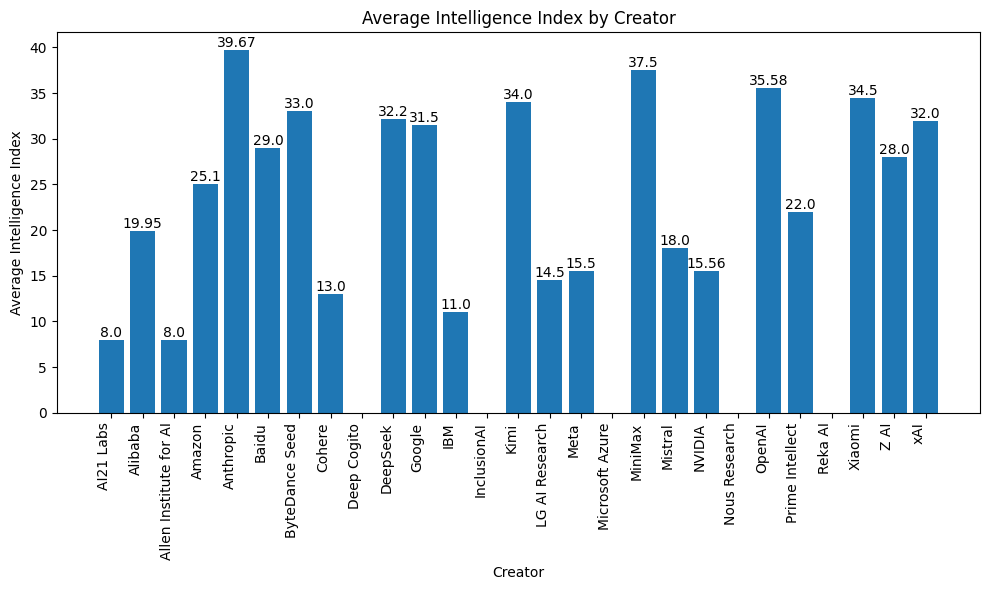

In [65]:
# Aggregate metrics by creator
creator_agg = clean_df.groupby('Creator').agg({
    'Intelligence_Index': 'mean',
    'Price_USD_per_1M': 'mean',
    'Speed(median token/s)': 'mean',
    'Latency (First Answer Chunk /s)': 'mean'
}).round(2)

# Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    creator_agg.index,
    creator_agg['Intelligence_Index']
)

plt.title('Average Intelligence Index by Creator')
plt.xlabel('Creator')
plt.ylabel('Average Intelligence Index')
plt.xticks(rotation=90, ha='right')

# Add value labels
for i, v in enumerate(creator_agg['Intelligence_Index']):
    plt.text(i, v, round(v, 2), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('creator_avg_intelligence.png', dpi=300)
plt.show()


**Dashboard 6 — Identifying Balanced Models**

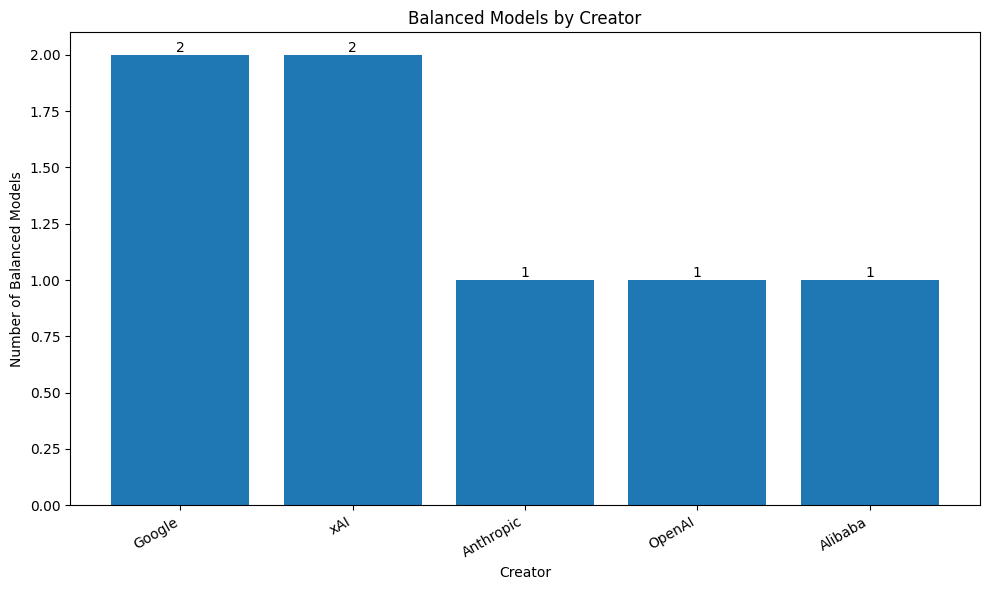

In [66]:
# Calculate global averages
avg_intelligence = clean_df['Intelligence_Index'].mean()
avg_speed = clean_df['Speed(median token/s)'].mean()
avg_latency = clean_df['Latency (First Answer Chunk /s)'].mean()

# Filter balanced models
balanced_models = clean_df[
    (clean_df['Intelligence_Index'] >= avg_intelligence) &
    (clean_df['Speed(median token/s)'] >= avg_speed) &
    (clean_df['Latency (First Answer Chunk /s)'] <= avg_latency)
]

#Chart
import matplotlib.pyplot as plt

# Count balanced models per creator
balanced_count = balanced_models['Creator'].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    balanced_count.index,
    balanced_count.values
)

plt.title('Balanced Models by Creator')
plt.xlabel('Creator')
plt.ylabel('Number of Balanced Models')
plt.xticks(rotation=30, ha='right')

# Add value labels
for i, v in enumerate(balanced_count.values):
    plt.text(i, v, v, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('balanced_models_by_creator.png', dpi=300)
plt.show()


**Dashboard 7 — Use-Case-Driven Model Analysis**

In [67]:
# Recalculate averages
avg_intelligence = clean_df['Intelligence_Index'].mean()
avg_speed = clean_df['Speed(median token/s)'].mean()
avg_latency = clean_df['Latency (First Answer Chunk /s)'].mean()
avg_value = clean_df['Intelligence_per_USD'].mean()


In [68]:
# Assign use cases
def assign_use_case(row):
    if row['Latency (First Answer Chunk /s)'] <= avg_latency and row['Speed(median token/s)'] >= avg_speed:
        return 'Developers (Real-Time Apps)'
    elif row['Intelligence_Index'] >= avg_intelligence and row['Context_Window_Tokens'] >= clean_df['Context_Window_Tokens'].quantile(0.75):
        return 'Researchers'
    elif row['Intelligence_per_USD'] >= avg_value:
        return 'Business Analysts'
    elif row['Intelligence_Index'] >= avg_intelligence:
        return 'Data Scientists & ML Engineers'
    else:
        return 'General / Others'

clean_df['Use_Case'] = clean_df.apply(assign_use_case, axis=1)

use_case_counts = clean_df['Use_Case'].value_counts()
use_case_counts



Use_Case
General / Others                  50
Developers (Real-Time Apps)       38
Researchers                       19
Data Scientists & ML Engineers    16
Business Analysts                 15
Name: count, dtype: int64

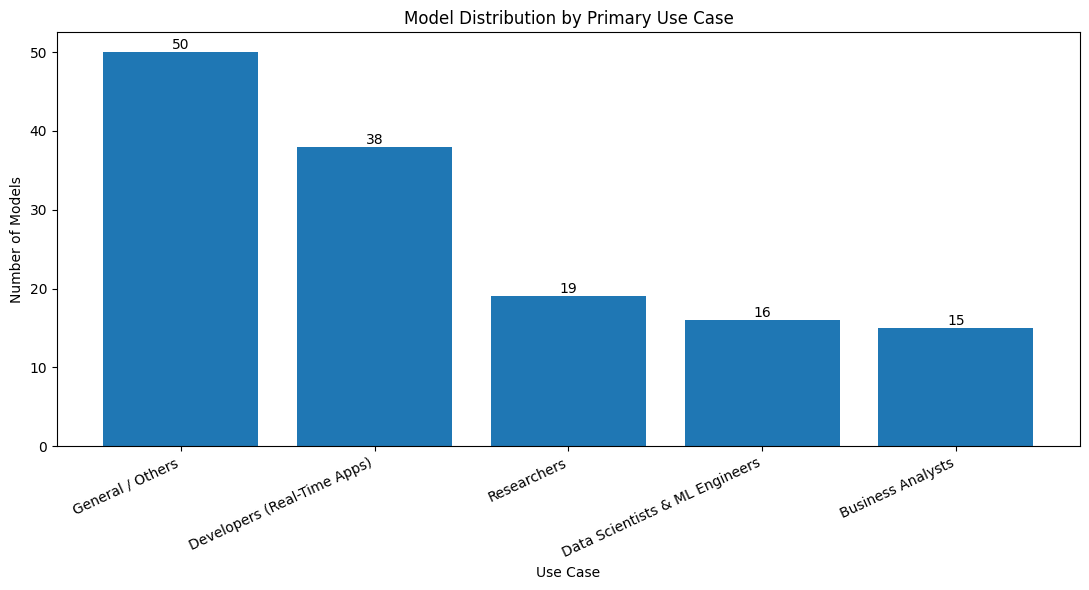

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.bar(
    use_case_counts.index,
    use_case_counts.values
)

plt.title('Model Distribution by Primary Use Case')
plt.xlabel('Use Case')
plt.ylabel('Number of Models')
plt.xticks(rotation=25, ha='right')

# Add value labels
for i, v in enumerate(use_case_counts.values):
    plt.text(i, v, v, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('use_case_driven_model_analysis.png', dpi=300)
plt.show()


## **Conclusions**

- There is no universally best AI model
- Higher price does not guarantee higher intelligence
- Speed and latency are distinct performance dimensions
- Balanced models are uncommon; trade-offs are unavoidable
- Model selection must be use-case driven, not brand-driven